# Лабораторная работа 2. Пропуски, кодирование категорий, масштабирование

По материалам курса и примеру [handling_missing_norm.ipynb](https://nbviewer.org/github/ugapanyuk/courses_current/blob/main/notebooks/missing/handling_missing_norm.ipynb); дополнительно — [missing.ipynb](https://nbviewer.org/github/ugapanyuk/courses_current/blob/main/notebooks/features/missing.ipynb) (пропуски).

**Датасеты:**
- **melb_data.csv** — рынок недвижимости Мельбурна (Kaggle Melbourne Housing Snapshot): много числовых признаков, пропуски в Car, BuildingArea, YearBuilt, CouncilArea; категориальные Suburb, Type, Method, Regionname и др.
- **StudentsPerformance.csv** — успеваемость студентов: категориальные gender, race/ethnicity, parental level of education, lunch, test preparation course; целевые числовые баллы. В файле пропусков нет — раздел кодирования и масштабирования строим на нём; обработка пропусков — на Melbourne.


## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, MissingIndicator

%matplotlib inline
sns.set(style="ticks")


# Часть 1. Датасет Melbourne — загрузка и пропуски в данных

In [2]:
melb = pd.read_csv('melb_data.csv', sep=',')
melb.shape

(13580, 21)

In [3]:
melb.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

In [4]:
melb.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [5]:
total_count = melb.shape[0]
print('Всего строк:', total_count)

Всего строк: 13580


In [6]:
# Пропущенные значения по колонкам
melb.isnull().sum()[melb.isnull().sum() > 0]

Car               62
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
dtype: int64

### Дополнение (курс [missing.ipynb](https://nbviewer.org/github/ugapanyuk/courses_current/blob/main/notebooks/features/missing.ipynb)): сводка по пропускам

**П.1.** Таблица: для каждой колонки с пропусками — число NaN и доля от всех строк.


In [7]:
melb_cols_with_na = [c for c in melb.columns if melb[c].isnull().sum() > 0]
na_summary = pd.DataFrame({
    'пропусков': [melb[c].isnull().sum() for c in melb_cols_with_na],
    'доля': [round(melb[c].isnull().mean(), 4) for c in melb_cols_with_na],
}, index=melb_cols_with_na)
na_summary


,пропусков,доля
Car,62,0.0046
BuildingArea,6450,0.4750
YearBuilt,5375,0.3958
CouncilArea,1369,0.1008


**П.2.** Удаление строк по `subset` (BuildingArea, YearBuilt, CouncilArea) и сравнение распределений до/после (наложенные гистограммы, `density=True`).


Исходный размер: (13580, 21) После dropna(subset): (6196, 21)


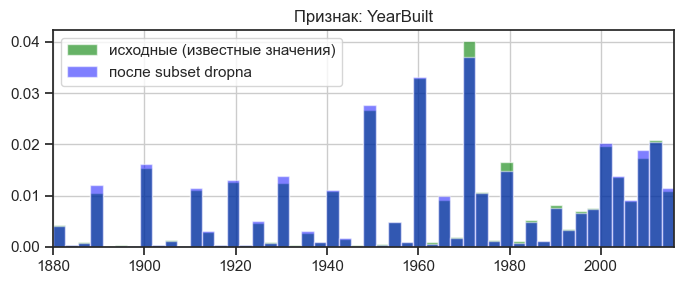

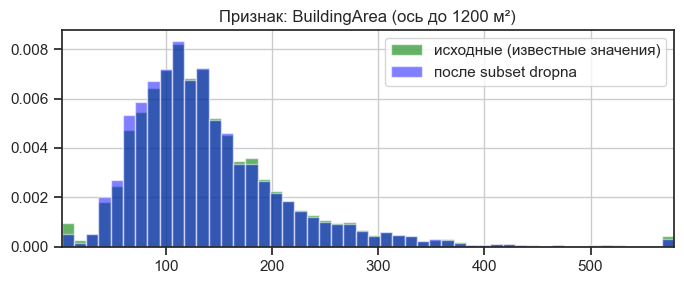

In [ ]:
melb_na_subset_cols = ['BuildingArea', 'YearBuilt', 'CouncilArea']
melb_drop_subset = melb.dropna(subset=melb_na_subset_cols)
print('Исходный размер:', melb.shape, 'После dropna(subset):', melb_drop_subset.shape)

def plot_hist_diff(old_ds, new_ds, cols):
    for c in cols:
        fig, ax = plt.subplots(figsize=(7, 3))
        s_old = old_ds[c].dropna()
        s_new = new_ds[c]
        lo2 = float(s_old.quantile(0.005))
        hi2 = float(s_old.quantile(0.995))
        if c == 'BuildingArea':
            hi2 = min(hi2, 1200.0)
            ax.set_title('Признак: ' + str(c))
        else:
            ax.set_title('Признак: ' + str(c))
        s_old = s_old.clip(lo2, hi2)
        s_new = s_new.clip(lo2, hi2)
        s_old.hist(bins=50, ax=ax, density=True, color='green', alpha=0.6,
                   label='исходные (известные значения)')
        s_new.hist(bins=50, ax=ax, density=True, color='blue', alpha=0.5,
                   label='после subset dropna')
        ax.set_xlim(lo2, hi2)
        ax.legend()
        plt.tight_layout()
        plt.show()

plot_hist_diff(melb, melb_drop_subset, ['YearBuilt', 'BuildingArea'])


**П.3.** Функция импьютации одного столбца и сравнение стратегий через KDE (`impute_column`, `research_impute_numeric_column` по аналогии с лекцией).


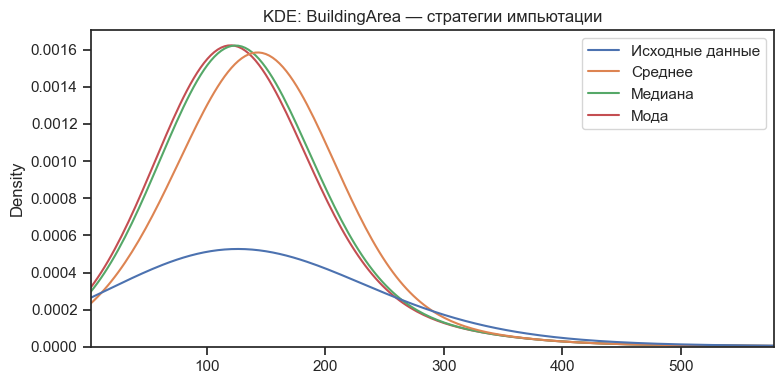

In [9]:
def impute_column(dataset, column, strategy_param, fill_value_param=None):
    temp = dataset[[column]].values
    indicator = MissingIndicator()
    mask = indicator.fit_transform(temp)
    imputer = SimpleImputer(strategy=strategy_param, fill_value=fill_value_param)
    all_data = imputer.fit_transform(temp).ravel()
    missed = temp[mask.ravel()]
    filled = all_data[mask.ravel()]
    return all_data, filled, missed


def research_impute_numeric_column(dataset, num_column, const_value=None):
    strategy_params = ['mean', 'median', 'most_frequent', 'constant']
    strategy_names = ['Среднее', 'Медиана', 'Мода', None]
    if const_value is not None:
        strategy_names[3] = 'Константа = ' + str(round(float(const_value), 2))
    orig = dataset[num_column].values
    new_df = pd.DataFrame({'Исходные данные': orig})
    for i, strategy in enumerate(strategy_params):
        if strategy != 'constant':
            arr, _, _ = impute_column(dataset, num_column, strategy)
        else:
            if const_value is None:
                continue
            arr, _, _ = impute_column(dataset, num_column, strategy, fill_value_param=const_value)
        new_df[strategy_names[i]] = arr

    clip_lo = float(pd.Series(orig).dropna().quantile(0.005))
    clip_hi = float(pd.Series(orig).dropna().quantile(0.995))
    if num_column == 'BuildingArea':
        clip_hi = min(clip_hi, 1200.0)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.kdeplot(data=new_df, ax=ax, clip=(clip_lo, clip_hi))
    ax.set_xlim(clip_lo, clip_hi)
    ax.set_title(f'KDE: {num_column} — стратегии импьютации')
    plt.tight_layout()
    plt.show()

research_impute_numeric_column(melb, 'BuildingArea')


**П.4.** Заполнение «хвостом» для асимметричного распределения: \(Q_3 + 3 \cdot IQR\).


IQR = 81.0 , extreme_value = 417.0


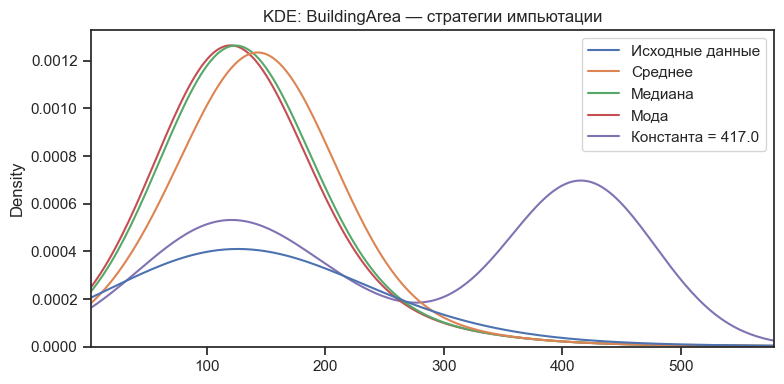

In [10]:
ba = melb['BuildingArea']
IQR_ba = ba.quantile(0.75) - ba.quantile(0.25)
BuildingArea_extreme = ba.quantile(0.75) + 3 * IQR_ba
print('IQR =', round(IQR_ba, 2), ', extreme_value =', round(BuildingArea_extreme, 2))
research_impute_numeric_column(melb, 'BuildingArea', const_value=BuildingArea_extreme)


**П.5.** Флаг пропуска — бинарный признак «значение отсутствовало» (BuildingArea, CouncilArea).


In [11]:
melb_flags = melb[['BuildingArea', 'CouncilArea']].copy()

ind_ba = MissingIndicator()
melb_flags['BuildingArea_missing'] = ind_ba.fit_transform(melb_flags[['BuildingArea']]).astype(int).ravel()

ind_ca = MissingIndicator()
melb_flags['CouncilArea_missing'] = ind_ca.fit_transform(melb_flags[['CouncilArea']]).astype(int).ravel()

melb_flags[['BuildingArea', 'CouncilArea', 'BuildingArea_missing', 'CouncilArea_missing']].head(12)


,BuildingArea,CouncilArea,BuildingArea_missing,CouncilArea_missing
0,NaN,Yarra,1,0
1,79.0,Yarra,0,0
2,150.0,Yarra,0,0
3,NaN,Yarra,1,0
4,142.0,Yarra,0,0
5,NaN,Yarra,1,0
6,210.0,Yarra,0,0
7,107.0,Yarra,0,0
8,NaN,Yarra,1,0
9,75.0,Yarra,0,0


### Простые стратегии: удаление или заполнение нулями

- Удаление колонок с любыми пропусками: `dropna(axis=1, how='any')`
- Удаление строк с любыми пропусками: `dropna(axis=0, how='any')`
- Заполнение всех пропусков нулём: `fillna(0)` — для смешанных данных часто **некорректно** (категории, год постройки и т.д.)

In [12]:
# Удаление колонок с хотя бы одним пропуском
melb_drop_cols = melb.dropna(axis=1, how='any')
(melb.shape, melb_drop_cols.shape)

((13580, 21), (13580, 17))

In [13]:
# Удаление строк с хотя бы одним пропуском
melb_drop_rows = melb.dropna(axis=0, how='any')
(melb.shape, melb_drop_rows.shape)

((13580, 21), (6196, 21))

In [14]:
# Заполнение нулями (демонстрация — для этого датасета осмысленнее импьютация ниже)
melb_fill0 = melb.fillna(0)
melb_fill0.isnull().sum().sum()

np.int64(0)

## Импьютация (imputation) числовых признаков

Используем [SimpleImputer](https://scikit-learn.org/stable/modules/impute.html) и при необходимости `MissingIndicator`.

In [15]:
# Числовые колонки с пропусками
num_cols_missing = []
for col in melb.columns:
    n_null = melb[col].isnull().sum()
    dt = str(melb[col].dtype)
    if n_null > 0 and dt in ('float64', 'int64'):
        num_cols_missing.append(col)
        pct = round(100.0 * n_null / total_count, 2)
        print(f'{col}: dtype={dt}, пропусков={n_null} ({pct}%)')
num_cols_missing

Car: dtype=float64, пропусков=62 (0.46%)
BuildingArea: dtype=float64, пропусков=6450 (47.5%)
YearBuilt: dtype=float64, пропусков=5375 (39.58%)


['Car', 'BuildingArea', 'YearBuilt']

In [16]:
data_num = melb[num_cols_missing]
data_num.head()

,Car,BuildingArea,YearBuilt
0,1.0,NaN,NaN
1,0.0,79.0,1900.0
2,0.0,150.0,1900.0
3,1.0,NaN,NaN
4,2.0,142.0,2014.0


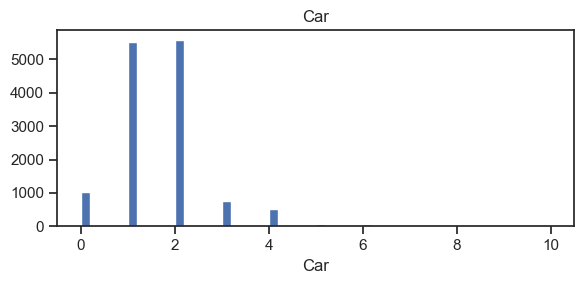

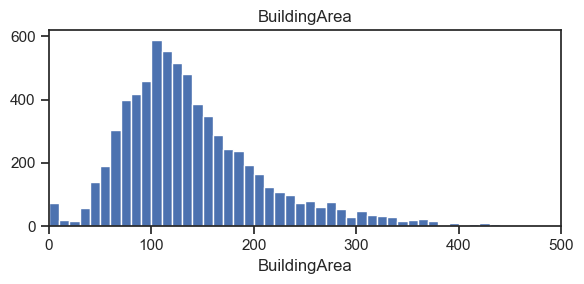

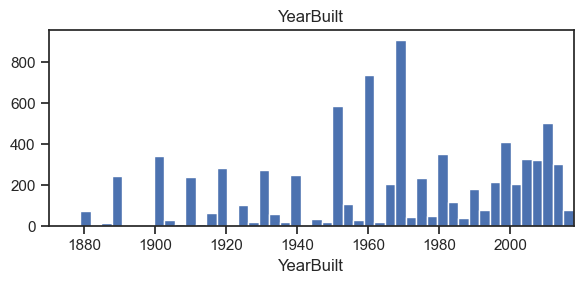

In [46]:
# Гистограммы числовых колонок с пропусками
BA_HIST_XMAX = 500
YEAR_BUILT_XMIN = 1870  # только для YearBuilt — ось с этого года
for col in data_num.columns:
    plt.figure(figsize=(6, 3))
    s = melb[col].dropna()
    if col == 'BuildingArea':
        plt.hist(s, bins=50, range=(0, BA_HIST_XMAX))
        plt.xlim(0, BA_HIST_XMAX)
    elif col == 'YearBuilt':
        ymax = float(s.max())
        plt.hist(s, bins=50, range=(YEAR_BUILT_XMIN, ymax))
        plt.xlim(YEAR_BUILT_XMIN, ymax)
    else:
        plt.hist(s, bins=50)
    plt.xlabel(col)
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [18]:
strategies = ['mean', 'median', 'most_frequent']

def test_num_impute_col(dataset, column, strategy_param):
    temp = dataset[[column]]
    indicator = MissingIndicator()
    mask = indicator.fit_transform(temp)
    imp = SimpleImputer(strategy=strategy_param)
    filled = imp.fit_transform(temp)
    only_filled = filled[mask.ravel()]
    return column, strategy_param, only_filled.size, only_filled.min(), only_filled.max()

In [19]:
# Пример: BuildingArea
melb[['BuildingArea']].describe()

,BuildingArea
count,7130.000000
mean,151.967650
std,541.014538
min,0.000000
25%,93.000000
50%,126.000000
75%,174.000000
max,44515.000000


In [20]:
[test_num_impute_col(melb, 'BuildingArea', s) for s in strategies]

[('BuildingArea',
  'mean',
  6450,
  np.float64(151.96764988779805),
  np.float64(151.96764988779805)),
 ('BuildingArea', 'median', 6450, np.float64(126.0), np.float64(126.0)),
 ('BuildingArea', 'most_frequent', 6450, np.float64(120.0), np.float64(120.0))]

In [21]:
# Пример: YearBuilt
[test_num_impute_col(melb, 'YearBuilt', s) for s in strategies]

[('YearBuilt',
  'mean',
  5375,
  np.float64(1964.6842169408897),
  np.float64(1964.6842169408897)),
 ('YearBuilt', 'median', 5375, np.float64(1970.0), np.float64(1970.0)),
 ('YearBuilt', 'most_frequent', 5375, np.float64(1970.0), np.float64(1970.0))]

In [22]:
# Car — целочисленный признак с небольшим числом пропусков
[test_num_impute_col(melb, 'Car', s) for s in strategies]

[('Car',
  'mean',
  62,
  np.float64(1.6100754549489569),
  np.float64(1.6100754549489569)),
 ('Car', 'median', 62, np.float64(2.0), np.float64(2.0)),
 ('Car', 'most_frequent', 62, np.float64(2.0), np.float64(2.0))]

## Импьютация категориальных признаков

Для `object` можно использовать стратегии `most_frequent` или `constant` в `SimpleImputer`.

In [23]:
cat_cols_missing = []
for col in melb.columns:
    n_null = melb[col].isnull().sum()
    dt = str(melb[col].dtype)
    if n_null > 0 and dt == 'object':
        cat_cols_missing.append(col)
        pct = round(100.0 * n_null / total_count, 2)
        print(f'{col}: пропусков={n_null} ({pct}%)')
cat_cols_missing

CouncilArea: пропусков=1369 (10.08%)


['CouncilArea']

In [24]:
council = melb[['CouncilArea']]
council['CouncilArea'].value_counts().head()

CouncilArea
Moreland         1163
Boroondara       1160
Moonee Valley     997
Darebin           934
Glen Eira         848
Name: count, dtype: int64

In [25]:
# Наиболее частое значение
imp_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
council_freq = imp_freq.fit_transform(council)
np.unique(council_freq, return_counts=False)[:10]

array(['Banyule', 'Bayside', 'Boroondara', 'Brimbank', 'Cardinia',
       'Casey', 'Darebin', 'Frankston', 'Glen Eira', 'Greater Dandenong'],
      dtype=object)

In [26]:
# Константа
imp_const = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
council_const = imp_const.fit_transform(council)
(council_const == 'Unknown').sum()

np.int64(1369)

# Часть 2. Students Performance — кодирование категориальных признаков

В этом файле **нет пропусков** — удобно сосредоточиться на кодировании.

In [27]:
students = pd.read_csv('StudentsPerformance.csv', sep=',')
students.shape

(1000, 8)

In [28]:
students.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [29]:
students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [30]:
students.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

## Label encoding (один столбец)

`LabelEncoder` удобен в первую очередь для **целевой** переменной; для признаков чаще используют `OrdinalEncoder` / one-hot.

In [31]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [32]:
le = LabelEncoder()
gender_enc = le.fit_transform(students['gender'])
le.classes_, gender_enc[:8]

(array(['female', 'male'], dtype=object), array([0, 0, 0, 1, 1, 0, 0, 1]))

## OrdinalEncoder (несколько столбцов)

Сначала заполним пропуски, если бы они были — здесь используем `constant` для единообразия с лекцией.

In [33]:
cat_subset = students[['gender', 'lunch', 'test preparation course']].copy()
imp_cat = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
cat_filled = imp_cat.fit_transform(cat_subset)
oe = OrdinalEncoder()
cat_oe = oe.fit_transform(cat_filled)
cat_oe[:5], oe.categories_

(array([[0., 1., 1.],
        [0., 1., 0.],
        [0., 1., 1.],
        [1., 0., 1.],
        [1., 1., 1.]]),
 [array(['female', 'male'], dtype=object),
  array(['free/reduced', 'standard'], dtype=object),
  array(['completed', 'none'], dtype=object)])

### Замечание по номинальным признакам

`LabelEncoder` / `OrdinalEncoder` задают порядок по **лексикографии**, что для номинальных шкал (город, тип) вводит искусственный порядок. Для таких признаков лучше **one-hot**.

## One-hot encoding

In [34]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_matrix = ohe.fit_transform(students[['gender']])
enc_matrix[:5], ohe.get_feature_names_out()

(array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.]]),
 array(['gender_female', 'gender_male'], dtype=object))

In [35]:
pd.get_dummies(students[['gender', 'lunch']], prefix=['g', 'lunch']).head()

,g_female,g_male,lunch_free/reduced,lunch_standard
0,True,False,False,True
1,True,False,False,True
2,True,False,False,True
3,False,True,True,False
4,False,True,False,True


### Порядковая шкала через `map` (пример)

Например: standard < free/reduced для типа питания — здесь это **условный** пример порядка для демонстрации.

In [36]:
tmp = students[['lunch']].copy()
tmp['lunch_ord'] = tmp['lunch'].map({'standard': 0, 'free/reduced': 1})
tmp.head(8)

,lunch,lunch_ord
0,standard,0
1,standard,0
2,standard,0
3,free/reduced,1
4,standard,0
5,standard,0
6,standard,0
7,free/reduced,1


# Часть 3. Масштабирование данных

**Масштабирование** — приведение признаков к сопоставимому диапазону (в отличие от *нормализации* распределения).

- **MinMaxScaler:** значения в отрезке [0, 1] (или заданный диапазон).
- **StandardScaler:** вычитание среднего, деление на СКО (типичный диапазон около [-3, 3]).

In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

## Melbourne: масштабирование цены (Price)

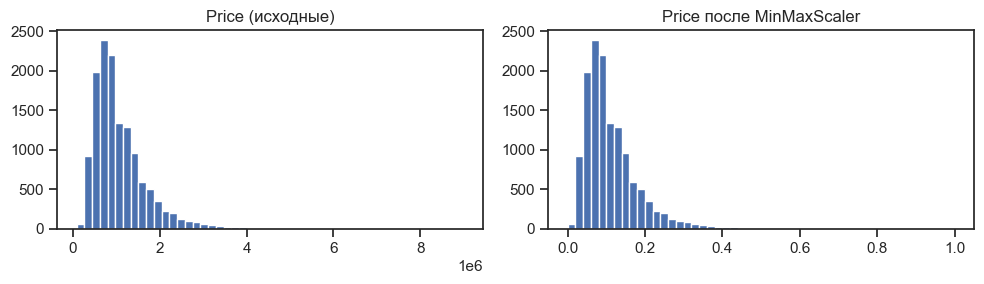

In [38]:
price = melb[['Price']].dropna()
sc_mm = MinMaxScaler()
price_mm = sc_mm.fit_transform(price)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(price.values, bins=50)
ax[0].set_title('Price (исходные)')
ax[1].hist(price_mm, bins=50)
ax[1].set_title('Price после MinMaxScaler')
plt.tight_layout()
plt.show()

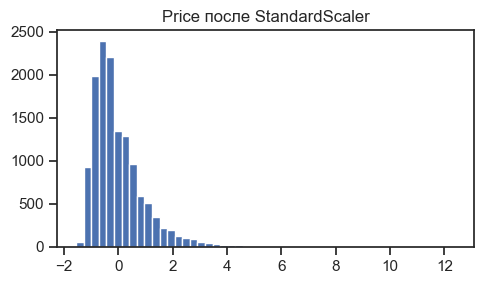

In [39]:
sc_std = StandardScaler()
price_std = sc_std.fit_transform(price)
plt.figure(figsize=(5, 3))
plt.hist(price_std, bins=50)
plt.title('Price после StandardScaler')
plt.tight_layout()
plt.show()

## Students: масштабирование баллов

In [40]:
scores = students[['math score', 'reading score', 'writing score']]
sc_mm2 = MinMaxScaler()
scores_mm = sc_mm2.fit_transform(scores)
pd.DataFrame(scores_mm, columns=scores.columns).describe().round(4)

,math score,reading score,writing score
count,1000.0000,1000.0000,1000.0000
mean,0.6609,0.6285,0.6450
std,0.1516,0.1759,0.1688
min,0.0000,0.0000,0.0000
25%,0.5700,0.5060,0.5306
50%,0.6600,0.6386,0.6556
75%,0.7700,0.7470,0.7667
max,1.0000,1.0000,1.0000


In [41]:
sc_std2 = StandardScaler()
scores_std = sc_std2.fit_transform(scores)
pd.DataFrame(scores_std, columns=scores.columns).describe().round(4)

,math score,reading score,writing score
count,1000.0000,1000.0000,1000.0000
mean,0.0000,0.0000,-0.0000
std,1.0005,1.0005,1.0005
min,-4.3607,-3.5750,-3.8223
25%,-0.5997,-0.6968,-0.6784
50%,-0.0059,0.0569,0.0623
75%,0.7199,0.6737,0.7207
max,2.2375,2.1127,2.1034


# Краткие выводы

1. **Melbourne:** пропуски в числовых (Car, BuildingArea, YearBuilt) и категориальном CouncilArea; сводная таблица долей пропусков; `dropna(subset=…)` с наложенными гистограммами до/после; функции `impute_column` и сравнение стратегий импьютации через KDE; заполнение «хвостом» IQR для BuildingArea; бинарные флаги пропусков; далее — `dropna`, `fillna`, `SimpleImputer`.
2. **Students:** без пропусков; показаны `LabelEncoder`, `OrdinalEncoder`, `OneHotEncoder`, `get_dummies`, ручное кодирование порядка через `map`.
3. **Масштабирование:** `MinMaxScaler` и `StandardScaler` на Price (Melbourne) и на трёх баллах (Students).

Для реальной модели имеет смысл собирать шаги в `sklearn.pipeline.Pipeline` и применять `fit` только на обучающей выборке.
